# Exploratory Data Analysis — CZM Surrogate Dataset

**Project:** UTokyo Aerospace FEA/ML — Cohesive Zone Model Surrogate  
**Dataset:** `data/raw_70000.csv` — 70,000 FEA simulation samples  
**Features:** 160 inputs (20 history timesteps × 8 mechanical state variables)  
**Target:** `label` — damage variable D ∈ [0, 1]

This notebook documents the known data characteristics that motivate pipeline design choices:
- Heavy class imbalance at D ≈ 0.9–1.0
- Sparse transition zone (D ≈ 0.3–0.7) — the physically critical regime
- DCB-only data (modeMixity = 0 throughout)

**Run order:** Execute all cells top-to-bottom with the conda env `fea-ml` active.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pipeline import config

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/raw_70000.csv'
print(f'Loading {DATA_PATH} ...')
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')

Loading ../data/raw_70000.csv ...
Shape: (70000, 161)  (70,000 rows × 161 cols)


---
## Section 1 — Schema Validation

Confirm the CSV matches the expected schema: 160 feature columns + 1 label, no nulls, correct dtypes.

In [2]:
# Column check
expected_cols = set(config.FEATURE_COLS + [config.LABEL_COL])
actual_cols   = set(df.columns)
missing = expected_cols - actual_cols
extra   = actual_cols  - expected_cols

print(f'Expected columns : {len(expected_cols)}')
print(f'Actual columns   : {len(actual_cols)}')
print(f'Missing          : {missing or "none"}')
print(f'Extra            : {extra   or "none"}')

# Null check
null_total = df.isnull().sum().sum()
print(f'\nTotal NaN values : {null_total}')

# Label range
print(f'Label min        : {df[config.LABEL_COL].min():.6f}')
print(f'Label max        : {df[config.LABEL_COL].max():.6f}')
print(f'Label dtype      : {df[config.LABEL_COL].dtype}')

print('\nSchema check: PASSED' if (not missing and not extra and null_total == 0) else 'FAILED')

Expected columns : 161
Actual columns   : 161
Missing          : none
Extra            : none

Total NaN values : 0
Label min        : 0.000000
Label max        : 1.000000
Label dtype      : float64

Schema check: PASSED


---
## Section 2 — Damage Distribution

The key data challenge: ~90% of samples have D ≈ 0.9–1.0.  
The transition zone (D = 0.3–0.7) controls physical accuracy but is severely underrepresented.

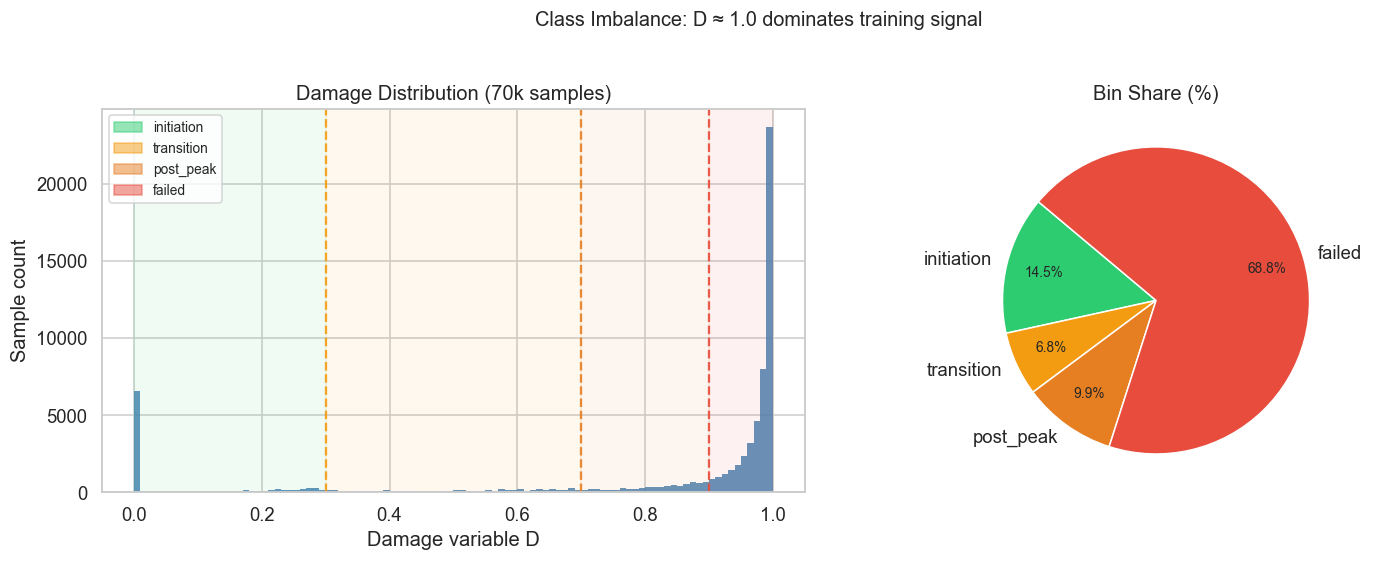

In [3]:
label = df[config.LABEL_COL]
bin_edges  = config.D_BIN_EDGES
bin_labels = config.D_BIN_LABELS
bin_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram ---
ax = axes[0]
ax.hist(label, bins=100, color='steelblue', edgecolor='none', alpha=0.85)
for edge, color in zip(bin_edges[1:-1], bin_colors[1:]):
    ax.axvline(edge, color=color, linestyle='--', linewidth=1.5, alpha=0.9)

# Shade bins
for i in range(len(bin_edges) - 1):
    ax.axvspan(bin_edges[i], bin_edges[i+1], alpha=0.07, color=bin_colors[i])

ax.set_xlabel('Damage variable D')
ax.set_ylabel('Sample count')
ax.set_title('Damage Distribution (70k samples)')
patches = [mpatches.Patch(color=bin_colors[i], alpha=0.5, label=bin_labels[i]) for i in range(4)]
ax.legend(handles=patches, loc='upper left', fontsize=9)

# --- Pie chart ---
bins_series = pd.cut(label, bins=bin_edges, labels=bin_labels, right=False)
counts = bins_series.value_counts().reindex(bin_labels)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=bin_labels,
    colors=bin_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
ax2.set_title('Bin Share (%)')

plt.suptitle('Class Imbalance: D ≈ 1.0 dominates training signal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 3 — Class Imbalance Quantification

Exact sample counts per damage bin. The transition zone (D = 0.3–0.7) is the model's weakest regime.  
Sample weights in the pipeline upweight this bin by ~20–50× relative to the fully-failed bin.

In [4]:
total = len(df)
print(f'Total samples: {total:,}\n')
print(f'{"Bin":<15} {"D range":<15} {"Count":>8}  {"Share":>7}  {"Inv. freq weight":>18}')
print('-' * 70)

bin_counts = counts.copy()
for bl, (lo, hi) in zip(bin_labels, zip(bin_edges, bin_edges[1:])):
    c = bin_counts[bl]
    freq = c / total
    inv_weight = 1.0 / freq if freq > 0 else float('inf')
    print(f'{bl:<15} [{lo:.1f}, {hi:.2f})  {c:>8,}  {100*freq:>6.2f}%  {inv_weight:>18.1f}×')

print('\nNote: weights are normalized so mean(weight)=1.0 in practice.')
print('The transition zone (D=0.3–0.7) receives the highest weight — this is the process zone.')

Total samples: 70,000

Bin             D range            Count    Share    Inv. freq weight
----------------------------------------------------------------------
initiation      [0.0, 0.30)    10,180   14.54%                 6.9×
transition      [0.3, 0.70)     4,734    6.76%                14.8×
post_peak       [0.7, 0.90)     6,906    9.87%                10.1×
failed          [0.9, 1.00)    48,180   68.83%                 1.5×

Note: weights are normalized so mean(weight)=1.0 in practice.
The transition zone (D=0.3–0.7) receives the highest weight — this is the process zone.


---
## Section 4 — Feature Statistics

Summary statistics for all 8 mechanical state variables, aggregated across all 20 history timesteps.

In [5]:
rows = []
for feat in config.FEATURE_NAMES:
    cols = [f'h{t}_{feat}' for t in range(config.N_TIMESTEPS)]
    vals = df[cols].values.ravel()
    rows.append({
        'Variable'  : feat,
        'Mean'      : vals.mean(),
        'Std'       : vals.std(),
        'Min'       : vals.min(),
        'P25'       : np.percentile(vals, 25),
        'Median'    : np.median(vals),
        'P75'       : np.percentile(vals, 75),
        'Max'       : vals.max(),
    })

stats_df = pd.DataFrame(rows).set_index('Variable')
print('Feature statistics (all 20 timesteps pooled):\n')
print(stats_df.to_string(float_format='{:.4e}'.format))

Feature statistics (all 20 timesteps pooled):

                    Mean        Std         Min         P25     Median        P75         Max
Variable                                                                                     
failureIndex  1.6945e+01 3.5321e+01  0.0000e+00  0.0000e+00 5.0437e-01 1.6681e+01  2.7712e+02
modeMixity    0.0000e+00 0.0000e+00  0.0000e+00  0.0000e+00 0.0000e+00 0.0000e+00  0.0000e+00
separN        5.0563e-03 1.0609e-02 -1.3713e-04 -6.1360e-05 1.5131e-04 5.0043e-03  8.3136e-02
separT1       0.0000e+00 0.0000e+00  0.0000e+00  0.0000e+00 0.0000e+00 0.0000e+00  0.0000e+00
separT2       0.0000e+00 0.0000e+00 -0.0000e+00  0.0000e+00 0.0000e+00 0.0000e+00 -0.0000e+00
tractN        1.0546e+01 1.5539e+01 -1.3713e+01 -6.1357e+00 1.0916e+01 2.6593e+01  3.0000e+01
tractT1      -8.4701e-08 4.7176e-07 -1.6400e-06 -3.7000e-07 0.0000e+00 1.4000e-07  1.3500e-06
tractT2       9.4643e-12 2.1445e-08 -3.2000e-07  0.0000e+00 0.0000e+00 0.0000e+00  3.1000e-07


---
## Section 5 — Time-Series Traces

Visualise how `separN`, `tractN`, and `failureIndex` evolve across the 20-step history window  
for sample elements at four different damage levels. This motivates the LSTM/GRU architecture.

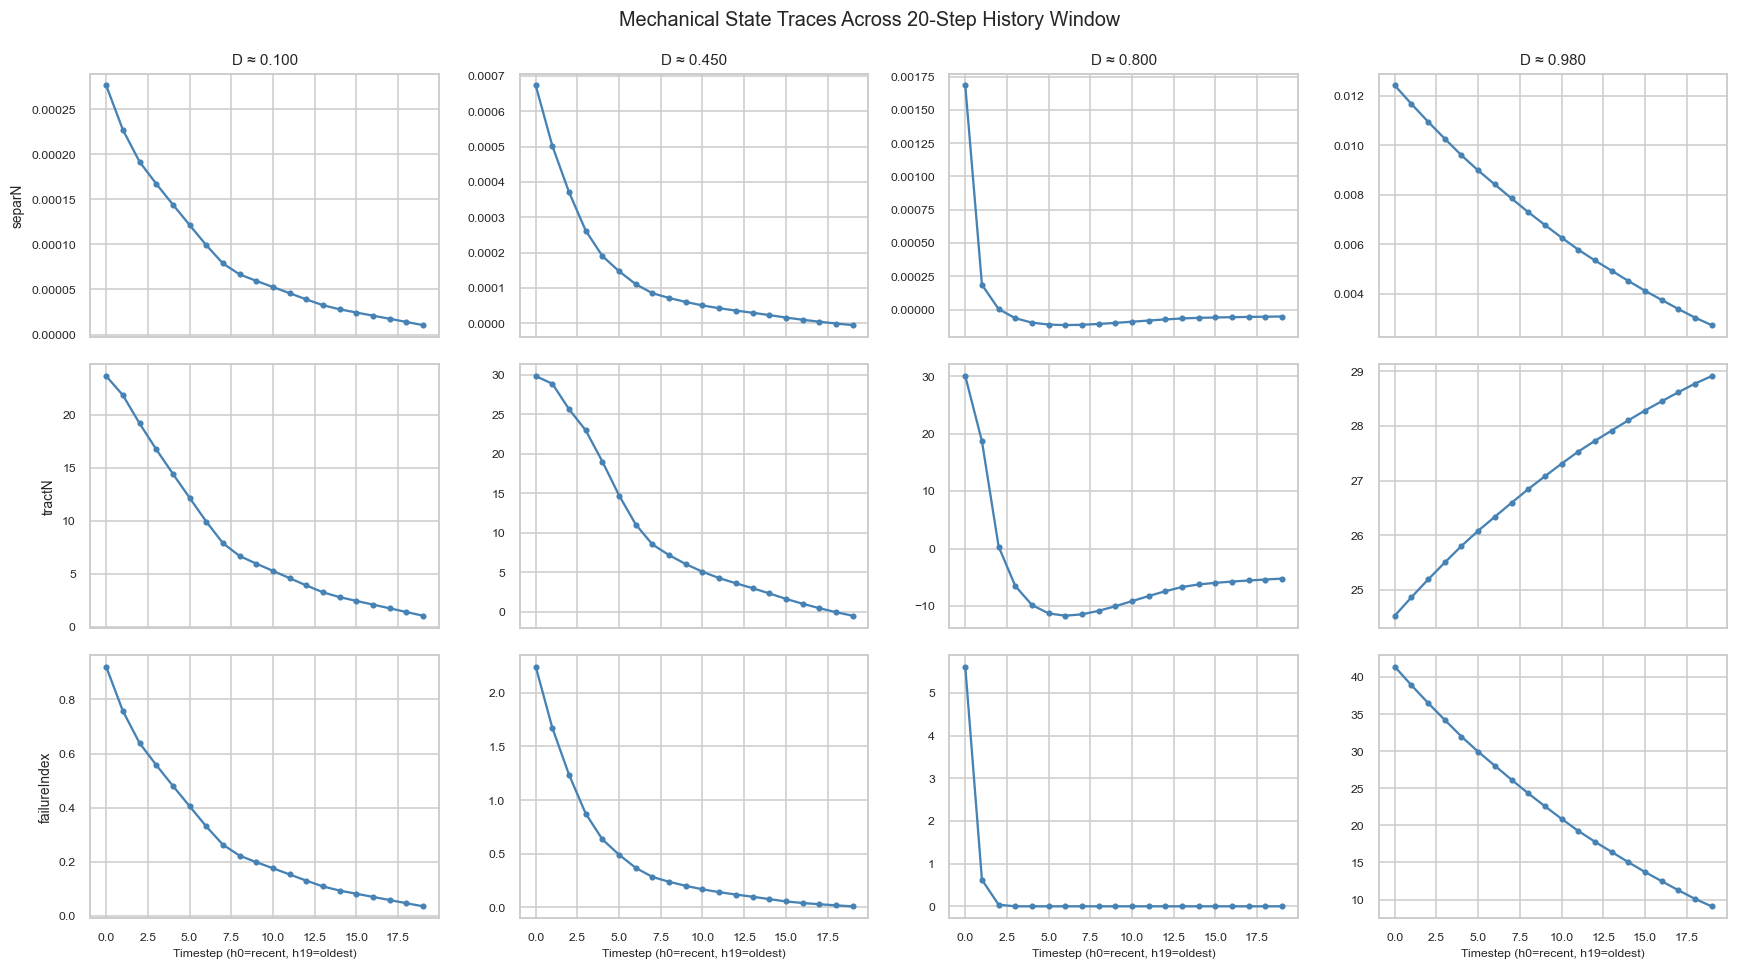

In [6]:
target_d_values = [0.1, 0.45, 0.80, 0.98]
trace_features  = ['separN', 'tractN', 'failureIndex']
timesteps       = list(range(config.N_TIMESTEPS))

fig, axes = plt.subplots(len(trace_features), len(target_d_values),
                         figsize=(16, 9), sharex=True)

for col_idx, target_d in enumerate(target_d_values):
    # Pick the sample closest to the target D value
    closest_idx = (df[config.LABEL_COL] - target_d).abs().idxmin()
    actual_d    = df.loc[closest_idx, config.LABEL_COL]

    for row_idx, feat in enumerate(trace_features):
        feat_cols = [f'h{t}_{feat}' for t in timesteps]
        values    = df.loc[closest_idx, feat_cols].values.astype(float)

        ax = axes[row_idx][col_idx]
        ax.plot(timesteps, values, marker='o', markersize=3, linewidth=1.5, color='steelblue')
        ax.set_title(f'D ≈ {actual_d:.3f}', fontsize=10) if row_idx == 0 else None
        ax.set_ylabel(feat, fontsize=9) if col_idx == 0 else None
        ax.tick_params(labelsize=8)
        if row_idx == len(trace_features) - 1:
            ax.set_xlabel('Timestep (h0=recent, h19=oldest)', fontsize=8)

plt.suptitle('Mechanical State Traces Across 20-Step History Window', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6 — modeMixity Audit

Confirm that all `h*_modeMixity` values are exactly 0.0.  
This documents the **DCB-only limitation**: the current dataset covers only pure Mode I fracture.
Models trained here have **zero generalization** to ENF (Mode II) or MMB (mixed-mode) loading.

In [7]:
mixity_cols = [f'h{t}_modeMixity' for t in range(config.N_TIMESTEPS)]
mixity_vals = df[mixity_cols].values

max_abs   = np.abs(mixity_vals).max()
n_nonzero = (mixity_vals != 0.0).sum()

print(f'modeMixity columns    : {len(mixity_cols)}')
print(f'Non-zero values       : {n_nonzero}')
print(f'Max absolute value    : {max_abs}')

if n_nonzero == 0:
    print('\nResult: All modeMixity = 0.0 — pure Mode I (DCB) data ONLY.')
    print('Implication: This model cannot generalise to:')
    print('  • ENF (End-Notched Flexure) — Mode II shear-dominated fracture')
    print('  • MMB (Mixed-Mode Bending)  — combined Mode I + II')
    print('\nFuture work: run FEA under ENF and MMB configs and add to training data.')
else:
    print(f'\nWARNING: {n_nonzero} non-zero modeMixity values found — dataset may contain ENF/MMB samples.')

modeMixity columns    : 20
Non-zero values       : 0
Max absolute value    : 0.0

Result: All modeMixity = 0.0 — pure Mode I (DCB) data ONLY.
Implication: This model cannot generalise to:
  • ENF (End-Notched Flexure) — Mode II shear-dominated fracture
  • MMB (Mixed-Mode Bending)  — combined Mode I + II

Future work: run FEA under ENF and MMB configs and add to training data.
